
# Evaluation of outlier detection estimators

This example compares two outlier detection algorithms, namely
`local_outlier_factor` (LOF) and `isolation_forest` (IForest), on
real-world datasets available in :class:`sklearn.datasets`. The goal is to show
that different algorithms perform well on different datasets and contrast their
training speed and sensitivity to hyperparameters.

The algorithms are trained (without labels) on the whole dataset assumed to
contain outliers.

1. The ROC curves are computed using knowledge of the ground-truth labels
   and displayed using :class:`~sklearn.metrics.RocCurveDisplay`.

2. The performance is assessed in terms of the ROC-AUC.


In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

## Dataset preprocessing and model training

Different outlier detection models require different preprocessing. In the
presence of categorical variables,
:class:`~sklearn.preprocessing.OrdinalEncoder` is often a good strategy for
tree-based models such as :class:`~sklearn.ensemble.IsolationForest`, whereas
neighbors-based models such as :class:`~sklearn.neighbors.LocalOutlierFactor`
would be impacted by the ordering induced by ordinal encoding. To avoid
inducing an ordering, on should rather use
:class:`~sklearn.preprocessing.OneHotEncoder`.

Neighbors-based models may also require scaling of the numerical features (see
for instance `neighbors_scaling`). In the presence of outliers, a good
option is to use a :class:`~sklearn.preprocessing.RobustScaler`.



### Create an outlier detection estimator based on its name
    

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn import pipeline
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    StandardScaler,
    MinMaxScaler
)


In [ ]:
preprocessor_IF = ColumnTransformer(
    transformers=[
        (
            "categorical", OrdinalEncoder(), make_column_selector(dtype_include=[object, "category"])
        ),
    ],
    remainder="passthrough",
)

In [ ]:
preprocessor_LOF = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(drop='first', sparse_output=False), make_column_selector(dtype_include=[object, "category"])),
        ("numerical", RobustScaler(), make_column_selector(dtype_exclude=[object, "category"]),),
    ],
    remainder="drop",
)

In [ ]:
preprocessors = {
    "IF": preprocessor_IF,
    "LOF": preprocessor_LOF
}

In [ ]:
model_configs = {
    "IF": {
        "model": IsolationForest(random_state=42),
        "preprocessor": preprocessor_IF
    },
    "LOF": {
        "model": LocalOutlierFactor(),
        "preprocessor": preprocessor_LOF
    }
}

In [ ]:
"""def run_experiment(X, y, dataset_name):
  fig, ax = plt.subplots(figsize=(8, 6))

  for name, config in model_configs.items():
    pipeline = make_pipeline(config["preprocessor"], config["model"])
    pipeline.fit(X)

    if name == "LOF":
      y_score = pipeline[-1].negative_outlier_factor_
    else:
      y_score = pipeline.decision_function(X)

    RocCurveDisplay.from_predictions(y, y_score, name=name, ax=ax, pos_label=0)

  ax.set_title(f"ROC Curve - {dataset_name}")
"""

In [ ]:
def run_experiment(X, y, dataset_name):
  fig, ax = plt.subplots(figsize=(8, 6))

  for name, config in model_configs.items():
    pipeline = make_pipeline(config["preprocessor"], config["model"])
    pipeline.fit(X)

    if name == "LOF":
      # negate -> higher score = more abnormal
      y_score = - pipeline[-1].negative_outlier_factor_
    else:
      # negate -> higher score = more abnormal
      y_score = - pipeline.decision_function(X)

    RocCurveDisplay.from_predictions(y, y_score, name=name, ax=ax, pos_label=1)

  ax.set_title(f"ROC Curve - {dataset_name}")
  plt.show()


### KDDCup99 - SA dataset

The `kddcup99_dataset` was generated using a closed network and
hand-injected attacks. The SA dataset is a subset of it obtained by simply
selecting all the normal data and an anomaly proportion of around 3%.



In [ ]:
import numpy as np

from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split

X, y = fetch_kddcup99(
    subset="SA", percent10=True, random_state=42, return_X_y=True, as_frame=True
)
y = (y != b"normal.").astype(np.int32)

X_SA, _, y_SA, _ = train_test_split(X, y, train_size=0.1, stratify=y, random_state=42)

n_samples, anomaly_frac = X_SA.shape[0], y_SA.mean()
print(f"{n_samples} datapoints with {y_SA.sum()} anomalies ({anomaly_frac:.02%})")

10065 datapoints with 338 anomalies (3.36%)


In [ ]:
X_SA.shape, X_SA.shape, y_SA.shape, y_SA.shape

((10065, 41), (10065, 41), (10065,), (10065,))

In [ ]:
X_SA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10065 entries, 26890 to 95188
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   duration                     10065 non-null  object
 1   protocol_type                10065 non-null  object
 2   service                      10065 non-null  object
 3   flag                         10065 non-null  object
 4   src_bytes                    10065 non-null  object
 5   dst_bytes                    10065 non-null  object
 6   land                         10065 non-null  object
 7   wrong_fragment               10065 non-null  object
 8   urgent                       10065 non-null  object
 9   hot                          10065 non-null  object
 10  num_failed_logins            10065 non-null  object
 11  logged_in                    10065 non-null  object
 12  num_compromised              10065 non-null  object
 13  root_shell                   100

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [ ]:
X_SA.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
26890,0,b'tcp',b'http',b'SF',289,498,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,77,255,1.0,0.0,0.01,0.03,0.0,0.0,0.0,0.0
35471,1,b'tcp',b'smtp',b'SF',829,329,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,137,157,0.46,0.05,0.01,0.01,0.01,0.0,0.0,0.0
37027,0,b'tcp',b'http',b'SF',305,2698,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,5,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,255,255,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80164,2630,b'udp',b'other',b'SF',145,105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,255,1,0.0,0.85,1.0,0.0,0.0,0.0,0.0,0.0
73649,0,b'tcp',b'ftp_data',b'SF',567,0,0,0,0,0,0,1,0,0,0,6,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,129,99,0.39,0.05,0.39,0.02,0.0,0.0,0.0,0.0


#### **Data Preparation**

In [ ]:
categorical_cols_SA = ["protocol_type", "service", "flag"]

In [ ]:
for col in X_SA.columns:
  if col not in categorical_cols_SA:
    X_SA[col] = X_SA[col].astype(float)

In [ ]:
X_SA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10065 entries, 26890 to 95188
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     10065 non-null  float64
 1   protocol_type                10065 non-null  object 
 2   service                      10065 non-null  object 
 3   flag                         10065 non-null  object 
 4   src_bytes                    10065 non-null  float64
 5   dst_bytes                    10065 non-null  float64
 6   land                         10065 non-null  float64
 7   wrong_fragment               10065 non-null  float64
 8   urgent                       10065 non-null  float64
 9   hot                          10065 non-null  float64
 10  num_failed_logins            10065 non-null  float64
 11  logged_in                    10065 non-null  float64
 12  num_compromised              10065 non-null  float64
 13  root_shell       

In [ ]:
X_SA.duplicated().sum()

np.int64(701)

In [ ]:
mask_non_duplicates = ~X_SA.duplicated(keep='first')

X_SA_clean = X_SA[mask_non_duplicates]
y_SA_clean = y_SA[mask_non_duplicates]

print(f"Removed {len(X_SA) - len(X_SA_clean)} duplicate rows")
print(f"New dataset shape: {X_SA_clean.shape}")

Removed 701 duplicate rows
New dataset shape: (9364, 41)


### Forest covertypes dataset

The `covtype_dataset` is a multiclass dataset where the target is the
dominant species of tree in a given patch of forest. It contains 54 features,
some of which ("Wilderness_Area" and "Soil_Type") are already binary encoded.
Though originally meant as a classification task, one can regard inliers as
samples encoded with label 2 and outliers as those with label 4.



In [ ]:
from sklearn.datasets import fetch_covtype

X, y = fetch_covtype(return_X_y=True, as_frame=True)
s = (y == 2) + (y == 4)
X = X.loc[s]
y = y.loc[s]
y = (y != 2).astype(np.int32)

X, _, y_forest, _ = train_test_split(X, y, train_size=0.05, stratify=y, random_state=42)
X_forest = X  # save X for later use

n_samples, anomaly_frac = X_forest.shape[0], y_forest.mean()
print(f"{n_samples} datapoints with {y_forest.sum()} anomalies ({anomaly_frac:.02%})")

14302 datapoints with 137 anomalies (0.96%)


### Ames Housing dataset

The [Ames housing dataset](http://www.openml.org/d/43926) is originally a
regression dataset where the target are sales prices of houses in Ames, Iowa.
Here we convert it into an outlier detection problem by regarding houses with
price over 70 USD/sqft. To make the problem easier, we drop intermediate
prices between 40 and 70 USD/sqft.



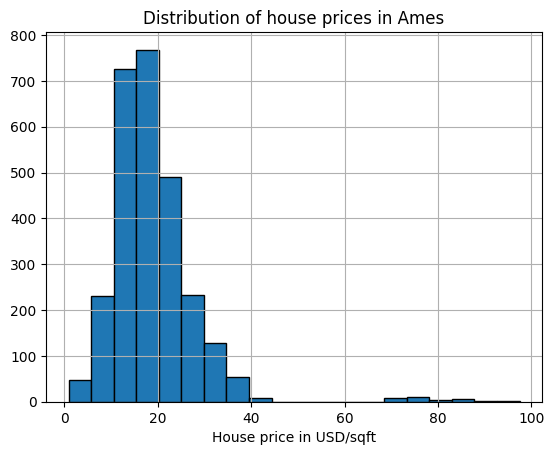

In [ ]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

X, y = fetch_openml(name="ames_housing", version=1, return_X_y=True, as_frame=True)
y = y.div(X["Lot_Area"])

# None values in pandas 1.5.1 were mapped to np.nan in pandas 2.0.1
X["Misc_Feature"] = X["Misc_Feature"].cat.add_categories("NoInfo").fillna("NoInfo")
X["Mas_Vnr_Type"] = X["Mas_Vnr_Type"].cat.add_categories("NoInfo").fillna("NoInfo")

X.drop(columns="Lot_Area", inplace=True)
mask = (y < 40) | (y > 70)
X_housing = X.loc[mask]
y_housing = y.loc[mask]
y_housing.hist(bins=20, edgecolor="black")
plt.xlabel("House price in USD/sqft")
_ = plt.title("Distribution of house prices in Ames")

In [ ]:
y_housing = (y_housing > 70).astype(np.int32)

n_samples, anomaly_frac = X_housing.shape[0], y_housing.mean()
print(f"{n_samples} datapoints with {y_housing.sum()} anomalies ({anomaly_frac:.02%})")

2714 datapoints with 30 anomalies (1.11%)


In [ ]:
X_housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2714 entries, 0 to 2929
Data columns (total 79 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   MS_SubClass         2714 non-null   category
 1   MS_Zoning           2714 non-null   category
 2   Lot_Frontage        2714 non-null   int64   
 3   Street              2714 non-null   category
 4   Alley               2714 non-null   category
 5   Lot_Shape           2714 non-null   category
 6   Land_Contour        2714 non-null   category
 7   Utilities           2714 non-null   category
 8   Lot_Config          2714 non-null   category
 9   Land_Slope          2714 non-null   category
 10  Neighborhood        2714 non-null   category
 11  Condition_1         2714 non-null   category
 12  Condition_2         2714 non-null   category
 13  Bldg_Type           2714 non-null   category
 14  House_Style         2714 non-null   category
 15  Overall_Qual        2714 non-null   categor

The dataset contains 46 categorical features. In this case it is easier use a
:class:`~sklearn.compose.make_column_selector` to find them instead of passing
a list made by hand.



### Cardiotocography dataset

The [Cardiotocography dataset](http://www.openml.org/d/1466) is a multiclass
dataset of fetal cardiotocograms, the classes being the fetal heart rate (FHR)
pattern encoded with labels from 1 to 10. Here we set class 3 (the minority
class) to represent the outliers. It contains 30 numerical features, some of
which are binary encoded and some are continuous.



In [72]:
X, y = fetch_openml(name="cardiotocography", version=1, return_X_y=True, as_frame=True)
X_ctg = X  # save X for later use
s = y == "3"
y_ctg = s.astype(np.int32)

n_samples, anomaly_frac = X_ctg.shape[0], y_ctg.mean()
print(f"{n_samples} datapoints with {y_ctg.sum()} anomalies ({anomaly_frac:.02%})")

2126 datapoints with 53 anomalies (2.49%)


## Plot and interpret results

The algorithm performance relates to how good the true positive rate (TPR) is
at low value of the false positive rate (FPR). The best algorithms have the
curve on the top-left of the plot and the area under curve (AUC) close to 1.
The diagonal dashed line represents a random classification of outliers and
inliers.



#### **KDDCup99 - SA Dataset Results**

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


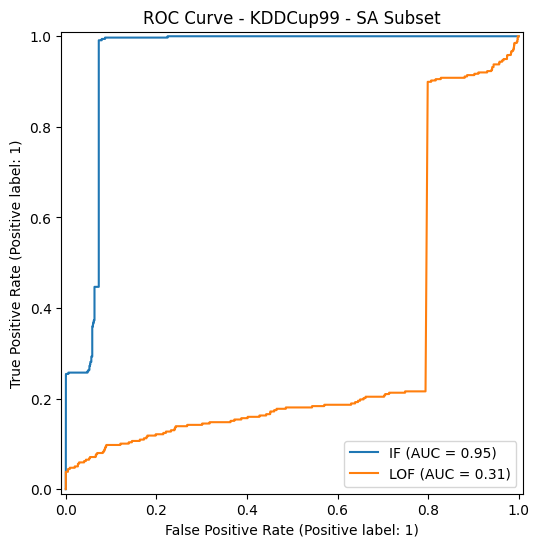

In [ ]:
run_experiment(X_SA, y_SA, "KDDCup99 - SA Subset")

The following plot is after dropping the duplicated rows.

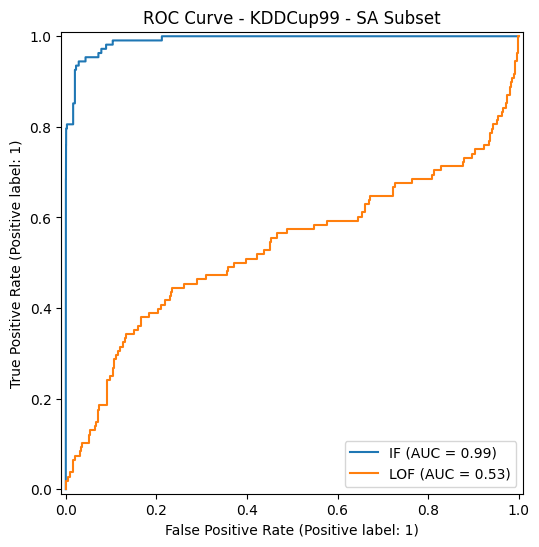

In [ ]:
run_experiment(X_SA_clean, y_SA_clean, "KDDCup99 - SA Subset")

#### **Forest Covertypes Dataset Results**

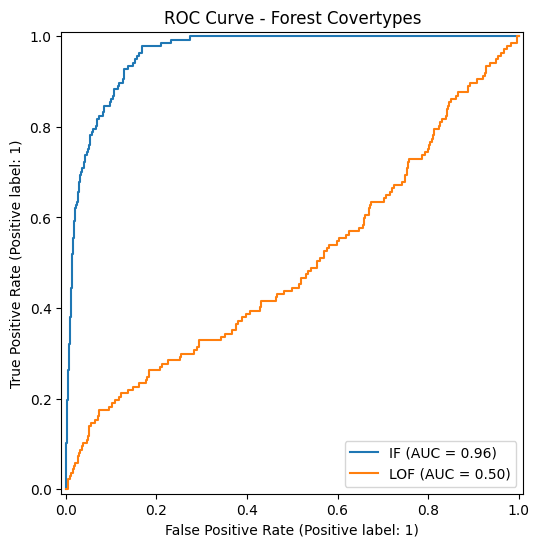

In [ ]:
run_experiment(X_forest, y_forest, "Forest Covertypes")

* Isolation forest acheived a good result on the Forest Covertype because tree-based models performs well on high-dimension data.
* Local outlier factor was randomly guessing because it is a distance-based model which struggles with high-dimention data.

#### **Ames Housing Dataset Results**

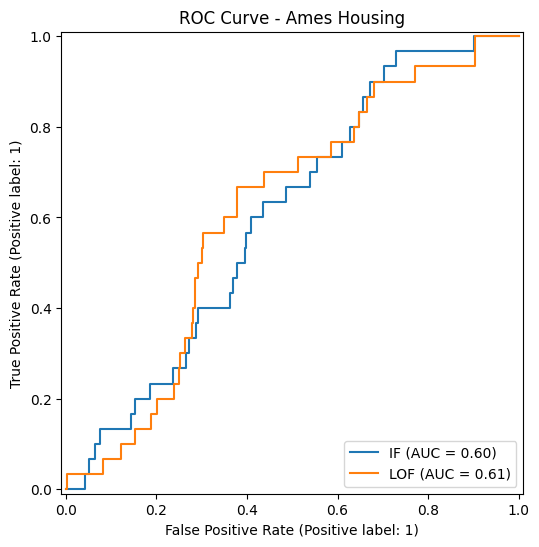

In [ ]:
run_experiment(X_housing, y_housing, "Ames Housing")

* Both IF and LOF are almost randomly guessing.


#### **Cardiotocography Dataset Results**

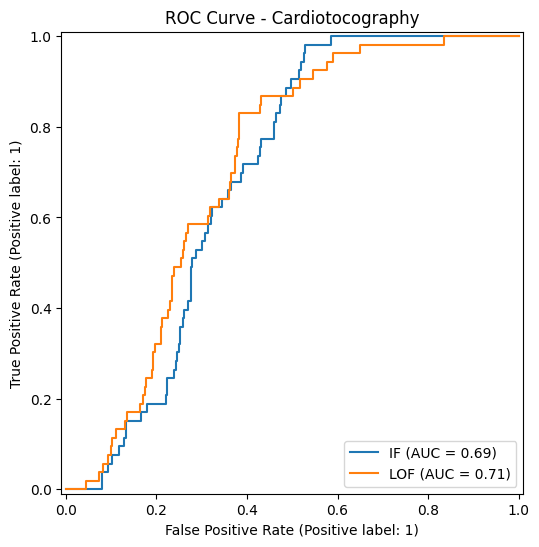

In [73]:
run_experiment(X_ctg, y_ctg, "Cardiotocography")

## Ablation study

In this section we explore the impact of the hyperparameter `n_neighbors` and
the choice of scaling the numerical variables on the LOF model. Here we use
the `covtype_dataset` dataset as the binary encoded categories introduce
a natural scale of euclidean distances between 0 and 1. We then want a scaling
method to avoid granting a privilege to non-binary features and that is robust
enough to outliers so that the task of finding them does not become too
difficult.



### Different Scalers on Forest Covertype Dataset

In [ ]:
scalers = {
    "RobustScaler": RobustScaler(),
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

Text(0.5, 1.0, 'Impact of Scalers (Forest Covertypes)')

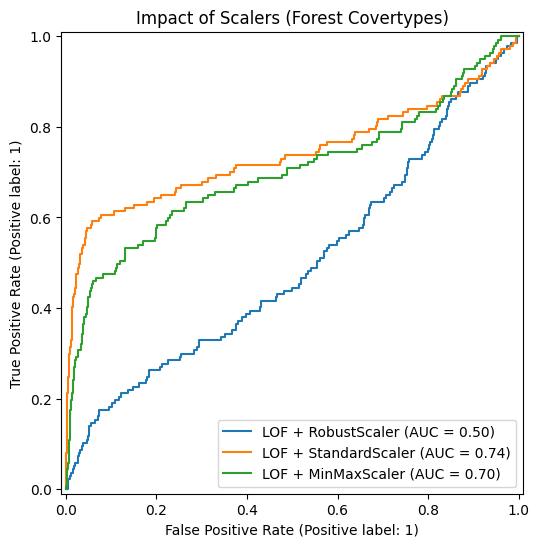

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, scaler in scalers.items():
  pipeline = make_pipeline(
      scaler,
      LocalOutlierFactor()
  )

  pipeline.fit(X_forest)
  y_score = - pipeline[-1].negative_outlier_factor_

  RocCurveDisplay.from_predictions(y_forest, y_score, name=f"LOF + {name}", ax=ax,pos_label=1)

ax.set_title("Impact of Scalers (Forest Covertypes)")

### Different `n_neighbors` on Forest Covertype Dataset

Text(0.5, 1.0, 'Impact of n_neighbors (Forest Covertypes)')

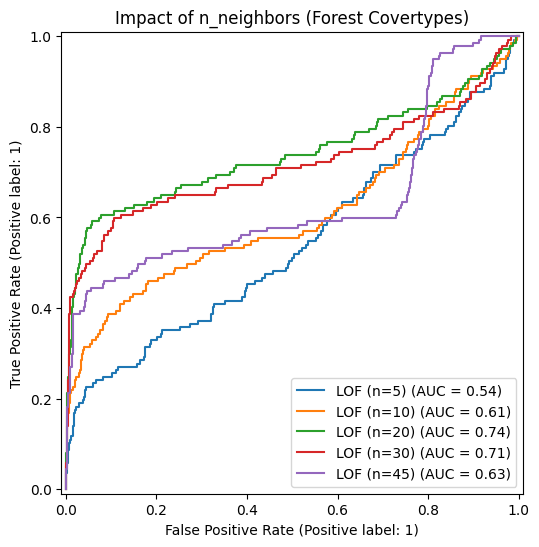

In [ ]:
n_neighbors = [5, 10, 20, 30, 45]

fig, ax = plt.subplots(figsize=(8, 6))

for n in n_neighbors:
  pipeline = make_pipeline(
      StandardScaler(),
      LocalOutlierFactor(n_neighbors=n)
  )

  pipeline.fit(X_forest)

  y_score = -pipeline[-1].negative_outlier_factor_

  RocCurveDisplay.from_predictions(y_forest, y_score, name=f"LOF (n={n})", ax=ax, pos_label=1)

ax.set_title("Impact of n_neighbors (Forest Covertypes)")

On the one hand, :class:`~sklearn.preprocessing.RobustScaler` scales each
feature independently by using the interquartile range (IQR) by default, which
is the range between the 25th and 75th percentiles of the data. It centers the
data by subtracting the median and then scale it by dividing by the IQR. The
IQR is robust to outliers: the median and interquartile range are less
affected by extreme values than the range, the mean and the standard
deviation. Furthermore, :class:`~sklearn.preprocessing.RobustScaler` does not
squash marginal outlier values, contrary to
:class:`~sklearn.preprocessing.StandardScaler`.

On the other hand, :class:`~sklearn.preprocessing.MinMaxScaler` scales each
feature individually such that its range maps into the range between zero and
one. If there are outliers in the data, they can skew it towards either the
minimum or maximum values, leading to a completely different distribution of
data with large marginal outliers: all non-outlier values can be collapsed
almost together as a result.

:class:`~sklearn.preprocessing.StandardScaler` and
:class:`~sklearn.preprocessing.SplineTransformer`. Please refer to their
respective documentation for more details.

